In [ ]:
"""
DNN Fraud Detection — Embedding + MLP (PyTorch)
================================================
Architecture:
  • Categorical cols  → individual Embedding layers → concatenated
  • Numerical cols    → passed directly (already scaled)
  • Concat            → BatchNorm → MLP with TAPERED residual skip connections
                        (512 → 256 → 128) → Sigmoid output

Device priority: CUDA → MPS (Apple Silicon) → CPU

Expects preprocessed outputs from the pipeline:
  preprocessed/train.csv
  preprocessed/val.csv
  preprocessed/test.csv
  preprocessed/column_metadata.pkl

Usage:
  python dnn_fraud.py              # train with default hyperparams
  python dnn_fraud.py --tune       # Optuna sweep over arch hyperparams
"""

import argparse
import pickle
import time
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR      = Path("preprocessed")
OUTPUT_DIR    = Path("models/dnn")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED          = 42
BATCH_SIZE    = 4096
MAX_EPOCHS    = 50
PATIENCE      = 7        # early stopping patience on val AUC
N_TUNE_TRIALS = 30       # Optuna trials when --tune is passed

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
def get_device():
    if torch.cuda.is_available():
        dev = torch.device("cuda")
    elif torch.backends.mps.is_available():
        dev = torch.device("mps")
    else:
        dev = torch.device("cpu")
    print(f"Using device: {dev}")
    return dev

DEVICE = get_device()


# ── Dataset ───────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    """
    Splits columns into:
      cat_data  — integer indices for embedding lookup  (LongTensor)
      num_data  — scaled floats                          (FloatTensor)
      labels    — 0/1                                    (FloatTensor)
    """
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y   = torch.tensor(df[target].values,   dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


def make_sampler(y_train_np):
    """WeightedRandomSampler → each mini-batch ~50/50 fraud/legit."""
    fraud_rate = y_train_np.mean()
    w_fraud    = 1.0 / fraud_rate
    w_legit    = 1.0 / (1.0 - fraud_rate)
    weights    = np.where(y_train_np == 1, w_fraud, w_legit)
    return WeightedRandomSampler(
        weights     = torch.DoubleTensor(weights),
        num_samples = len(weights),
        replacement = True,
    )


# ── Model ─────────────────────────────────────────────────────────────────────
class TaperedResidualBlock(nn.Module):
    """
    Residual block that projects from in_dim → out_dim.
    When in_dim != out_dim a linear shortcut aligns the skip connection,
    so gradients still flow cleanly at every width transition.
    """
    def __init__(self, in_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
            nn.BatchNorm1d(out_dim),
        )
        # Shortcut: project only when widths differ
        self.shortcut = (
            nn.Linear(in_dim, out_dim, bias=False)
            if in_dim != out_dim else nn.Identity()
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.shortcut(x) + self.block(x))


class EmbeddingMLP(nn.Module):
    """
    Embedding + MLP fraud classifier with tapered residual blocks.

    Each categorical column gets its own Embedding layer.
    Embedding dim uses the rule-of-thumb: min(embed_dim, max(4, vocab//2)).
    All embeddings + numerical features are concatenated, projected to
    hidden_dim (= first block width), then passed through a stack of
    tapered residual blocks that halve the width each time.

    Block widths: hidden_dim → hidden_dim//2 → hidden_dim//4
    Default with hidden_dim=512: 512 → 256 → 128

    Parameters
    ----------
    vocab_sizes  : dict  {col_name: vocab_size}
    num_features : int   number of numerical input features
    embed_dim    : int   max embedding dimension per column
    hidden_dim   : int   width of the FIRST residual block (should be 512)
    n_blocks     : int   number of residual blocks (3 recommended for tapering)
    dropout      : float dropout rate
    """
    def __init__(
        self,
        vocab_sizes : dict,
        num_features: int,
        embed_dim   : int   = 16,
        hidden_dim  : int   = 512,
        n_blocks    : int   = 3,
        dropout     : float = 0.3,
    ):
        super().__init__()
        self.cat_cols = list(vocab_sizes.keys())

        # Per-column embedding dims
        col_dims = {
            col: min(embed_dim, max(4, vocab_sizes[col] // 2))
            for col in self.cat_cols
        }
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], col_dims[col])
            for col in self.cat_cols
        ])

        embed_total = sum(col_dims.values())
        input_dim   = embed_total + num_features

        # Input projection → first block width
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Tapered residual blocks: each block halves the width
        # e.g. hidden_dim=512 → [512→256, 256→128, 128→64]
        # but we clamp so width never falls below 64
        dims = []
        w = hidden_dim
        for _ in range(n_blocks):
            next_w = max(w // 2, 64)
            dims.append((w, next_w))
            w = next_w

        self.blocks = nn.ModuleList([
            TaperedResidualBlock(in_d, out_d, dropout)
            for in_d, out_d in dims
        ])

        final_dim = dims[-1][1]   # width after last block

        # Output head
        self.head = nn.Sequential(
            nn.Linear(final_dim, final_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(final_dim // 2, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.01)

    def forward(self, cat, num):
        embeds = [emb(cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embeds + [num], dim=1)
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        return self.head(x).squeeze(1)   # raw logits, shape (B,)


# ── Focal Loss ────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    Focuses training on hard, misclassified examples.
    Helps with the heavy class imbalance in fraud datasets.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1.0 - prob)
        at   = torch.where(
            targets == 1,
            torch.full_like(pt, self.alpha),
            torch.full_like(pt, 1.0 - self.alpha),
        )
        return (at * (1.0 - pt) ** self.gamma * bce).mean()


# ── Train / eval loops ────────────────────────────────────────────────────────
def train_epoch(model, loader, optimiser, criterion, device):
    model.train()
    total_loss = 0.0
    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)
        optimiser.zero_grad()
        loss = criterion(model(cat, num), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_loader(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    for cat, num, y in loader:
        probs = torch.sigmoid(model(cat.to(device), num.to(device))).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.numpy())
    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    return roc_auc_score(labels, probs), average_precision_score(labels, probs), probs, labels


# ── Full training run ─────────────────────────────────────────────────────────
def run_training(train_ds, val_ds, test_ds,
                 vocab_sizes, n_num, hparams, device, verbose=True):

    # pin_memory causes issues on MPS
    pin = device.type == "cuda"

    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        sampler=make_sampler(train_ds.y.numpy()),
        num_workers=0, pin_memory=pin,
    )
    val_dl = DataLoader(val_ds,  batch_size=BATCH_SIZE * 2,
                        shuffle=False, num_workers=0)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE * 2,
                         shuffle=False, num_workers=0)

    model = EmbeddingMLP(
        vocab_sizes  = vocab_sizes,
        num_features = n_num,
        embed_dim    = hparams["embed_dim"],
        hidden_dim   = hparams["hidden_dim"],
        n_blocks     = hparams["n_blocks"],
        dropout      = hparams["dropout"],
    ).to(device)

    if verbose:
        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Trainable parameters: {n_params:,}")

    criterion = FocalLoss(alpha=hparams["focal_alpha"], gamma=hparams["focal_gamma"])
    optimiser = torch.optim.AdamW(
        model.parameters(),
        lr=hparams["lr"], weight_decay=hparams["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=MAX_EPOCHS, eta_min=1e-6
    )

    best_auc   = 0.0
    best_state = None
    patience_n = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        t0         = time.time()
        train_loss = train_epoch(model, train_dl, optimiser, criterion, device)
        val_auc, val_pr, _, _ = eval_loader(model, val_dl, device)
        scheduler.step()

        improved = val_auc > best_auc
        if improved:
            best_auc   = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_n = 0
        else:
            patience_n += 1

        if verbose:
            tick = " ✓" if improved else ""
            print(
                f"Epoch {epoch:03d} | loss {train_loss:.4f} | "
                f"val AUC {val_auc:.4f} | val PR-AUC {val_pr:.4f} | "
                f"{time.time()-t0:.1f}s{tick}"
            )

        if patience_n >= PATIENCE:
            if verbose:
                print(f"Early stopping triggered at epoch {epoch}.")
            break

    # Restore best checkpoint and evaluate on test
    model.load_state_dict(best_state)
    test_auc, test_pr, test_probs, test_labels = eval_loader(model, test_dl, device)

    if verbose:
        print(f"\nBest val  AUC  : {best_auc:.4f}")
        print(f"Test      AUC  : {test_auc:.4f}")
        print(f"Test   PR-AUC  : {test_pr:.4f}")
        # Threshold sweep for best F1
        from sklearn.metrics import f1_score
        thresholds = np.linspace(0.05, 0.95, 91)
        f1s        = [f1_score(test_labels, test_probs >= t, zero_division=0)
                      for t in thresholds]
        best_t     = thresholds[np.argmax(f1s)]
        print(f"Best threshold (F1 on test): {best_t:.2f}")
        print(classification_report(
            test_labels, test_probs >= best_t,
            target_names=["legit", "fraud"],
        ))

    return model, best_auc, test_auc, test_probs


# ── Optuna sweep ──────────────────────────────────────────────────────────────
def tune(train_ds, val_ds, vocab_sizes, n_num, device):
    def objective(trial):
        hp = {
            "embed_dim"   : trial.suggest_categorical("embed_dim",  [8, 16, 32]),
            # hidden_dim is now the FIRST (widest) block; taper does the rest
            "hidden_dim"  : trial.suggest_categorical("hidden_dim", [256, 512, 1024]),
            "n_blocks"    : trial.suggest_int("n_blocks", 2, 5),
            "dropout"     : trial.suggest_float("dropout", 0.1, 0.5),
            "lr"          : trial.suggest_float("lr", 1e-4, 3e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
            "focal_alpha" : trial.suggest_float("focal_alpha", 0.1, 0.5),
            "focal_gamma" : trial.suggest_float("focal_gamma", 1.0, 4.0),
        }
        _, val_auc, _, _ = run_training(
            train_ds, val_ds, val_ds,
            vocab_sizes, n_num, hp, device, verbose=False,
        )
        return val_auc

    study = optuna.create_study(
        direction     = "maximize",
        sampler       = optuna.samplers.TPESampler(seed=SEED),
        study_name    = "dnn_fraud_auc",
        storage       = "sqlite:///optuna_dnn.db",
        load_if_exists= True,
    )
    study.optimize(objective, n_trials=N_TUNE_TRIALS, show_progress_bar=True)
    print(f"\nBest val AUC : {study.best_value:.4f}")
    print(f"Best params  : {study.best_params}")
    return study.best_params


# ── Data loading ──────────────────────────────────────────────────────────────
def load_data():
    print("Loading preprocessed data …")
    with open(DATA_DIR / "column_metadata.pkl", "rb") as f:
        meta = pickle.load(f)

    target      = meta["target"]
    cat_cols    = meta["cat_cols"]
    vocab_sizes = meta["vocab_sizes"]

    train = pd.read_csv(DATA_DIR / "train.csv")
    val   = pd.read_csv(DATA_DIR / "val.csv")
    test  = pd.read_csv(DATA_DIR / "test.csv")

    # Filter to cols present in the dataframe (after feature engineering)
    cat_cols    = [c for c in cat_cols if c in train.columns]
    vocab_sizes = {c: vocab_sizes[c] for c in cat_cols}

    # Everything that is not a cat col or the target is treated as numerical
    num_cols = [c for c in train.columns if c not in cat_cols and c != target]

    print(f"  Cat features : {len(cat_cols)}")
    print(f"  Num features : {len(num_cols)}")
    print(f"  Train rows   : {len(train):,}  | fraud rate: {train[target].mean():.3%}")
    print(f"  Val rows     : {len(val):,}  | fraud rate: {val[target].mean():.3%}")

    train_ds = FraudDataset(train, cat_cols, num_cols, target)
    val_ds   = FraudDataset(val,   cat_cols, num_cols, target)
    test_ds  = FraudDataset(test,  cat_cols, num_cols, target)

    return train_ds, val_ds, test_ds, vocab_sizes, len(num_cols)


# ── Main ──────────────────────────────────────────────────────────────────────
DEFAULT_HPARAMS = {
    "embed_dim"   : 16,
    "hidden_dim"  : 512,   # first block width; tapers 512 → 256 → 128
    "n_blocks"    : 3,
    "dropout"     : 0.3,
    "lr"          : 5e-4,
    "weight_decay": 1e-4,
    "focal_alpha" : 0.25,
    "focal_gamma" : 2.0,
}


def main(do_tune: bool):
    train_ds, val_ds, test_ds, vocab_sizes, n_num = load_data()

    if do_tune:
        print(f"\nStarting Optuna DNN sweep ({N_TUNE_TRIALS} trials) …")
        best_params = tune(train_ds, val_ds, vocab_sizes, n_num, DEVICE)
        hparams = {**DEFAULT_HPARAMS, **best_params}
    else:
        hparams = DEFAULT_HPARAMS
        print(f"\nUsing default hyperparams: {hparams}")

    print("\n── Training final model ─────────────────────────────────────────")
    model, best_val_auc, test_auc, test_probs = run_training(
        train_ds, val_ds, test_ds,
        vocab_sizes, n_num, hparams, DEVICE, verbose=True,
    )

    # Save model and predictions
    model_path = OUTPUT_DIR / "dnn_fraud.pt"
    torch.save({
        "model_state": model.state_dict(),
        "hparams"    : hparams,
        "vocab_sizes": vocab_sizes,
        "n_num"      : n_num,
    }, model_path)
    print(f"\nModel saved → {model_path}")

    pd.DataFrame({"fraud_prob": test_probs}).to_csv(
        OUTPUT_DIR / "test_predictions.csv", index=False
    )



DO_TUNE = False  # Set to True to run Optuna sweep first
main(do_tune=DO_TUNE)



Using device: mps
Loading preprocessed data …


FileNotFoundError: [Errno 2] No such file or directory: 'preprocessed/column_metadata.pkl'

### Updated Model

In [2]:
pip install numpy pandas scikit-learn matplotlib seaborn optuna torch torchvision torchaudio tqdm joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 MB 61.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 62.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 60.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 31.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [optuna]12/13 [optuna]dio]]
Note: you may need to restart the kernel to use updated packages.


Device  : mps
Run dir : runs/fraud_nn/

Loading preprocessed data...
Categorical : 17
Numerical   : 246
pos_weight  : 27.58  (neg/pos ratio)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.8781      0.4858     5.3s
       2/8    0.6812      0.5661     4.3s
       3/8    0.5774      0.5838     4.2s
       4/8    0.4996      0.6361     4.4s
       5/8    0.4412      0.6584     4.3s
       6/8    0.3912      0.6203     4.4s
       7/8    0.3527      0.6761     4.4s
       8/8    0.3179      0.6729     4.4s
  [Trial  0] val_PR-AUC=0.6761  params={'hidden_dim': 256, 'lr': 0.0015751320499779737, 'weight_decay': 4.2079886696066345e-06, 'batch_size': 4096, 'la_k': 10, 'la_alpha': 0.3102922471479012, 'sched_patience': 3, 'sched_factor': 0.38493564427131044}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.7782      0.5509     8.0s
       2/8  

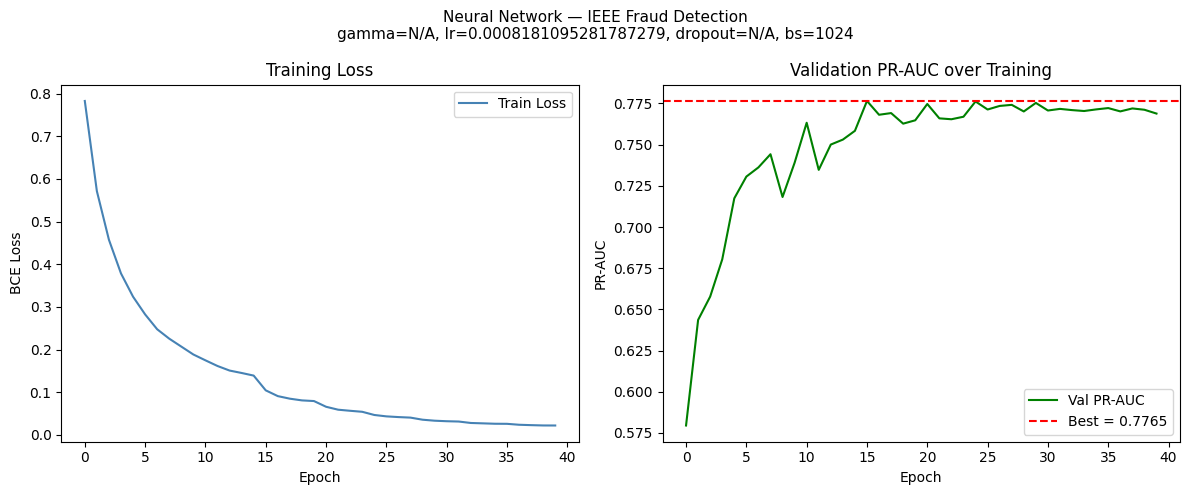

Training curves saved to runs/fraud_nn/nn_training_curves.png


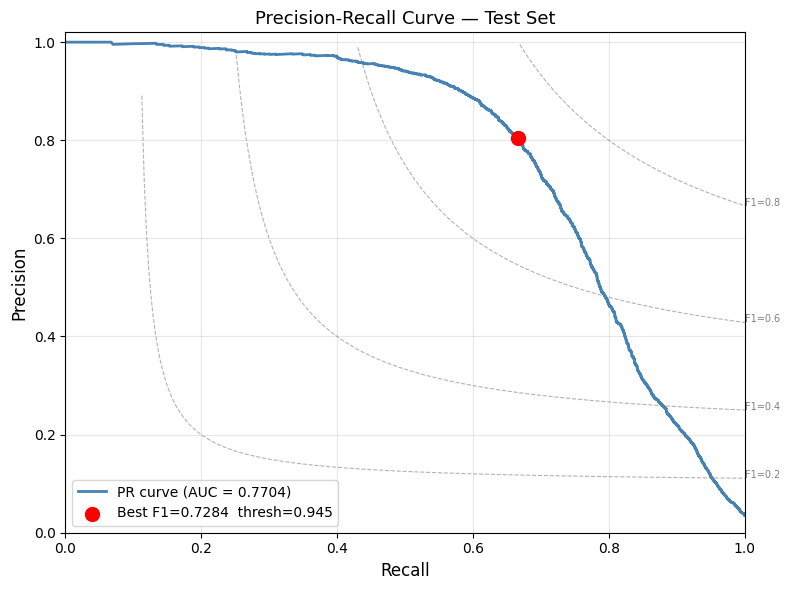

PR curve saved to runs/fraud_nn/pr_curve.png

  Final Results at best threshold = 0.945
  Test PR-AUC  : 0.7704
  Test F1      : 0.7284
  Test Recall  : 0.6660
  Test Precision: 0.8037
  Val  Recall  : 0.6534

Final metrics saved to runs/fraud_nn/final_metrics.json
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.80      0.67      0.73      3099

    accuracy                           0.98     88581
   macro avg       0.90      0.83      0.86     88581
weighted avg       0.98      0.98      0.98     88581

Model saved to runs/fraud_nn/nn_model.pt

  All outputs saved to: runs/fraud_nn/
    nn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    hp_search_results.csv
    final_metrics.json
    nn_model.pt


In [7]:
"""
IEEE-CIS Fraud Detection — Neural Network
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden layers: H → H/2 → H/4, each: Linear → BatchNorm → GELU
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - BCEWithLogitsLoss + pos_weight (class imbalance)
  - L2 regularisation via AdamW weight_decay
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def get_pos_weight(y_series, device):
    n_neg = (y_series == 0).sum()
    n_pos = (y_series == 1).sum()
    return torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(cat, num), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())

    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch,
        "val_pr_auc": val_pr,
        "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"],
        "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cpu"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    pos_weight,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=False,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model,
                    optimizer,
                    epoch,
                    val_pr,
                    config,
                    metadata,
                )

        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model,
                optimizer,
                epoch,
                val_pr,
                config,
                metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    pos_weight,
    metadata,
    device,
    n_trials=30,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
        }

        val_pr, _, _ = run_training(
            config,
            train_ds,
            val_ds,
            vocab_sizes,
            cat_cols,
            num_cols,
            pos_weight,
            metadata,
            device,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        callbacks=[
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)

    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
        
    run_dir = os.path.join("runs", "fraud_nn")
    n_epochs_full = 40

    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("train.csv")
    val_df = pd.read_csv("val.csv")
    test_df = pd.read_csv("test.csv")

    with open("column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    pos_weight = get_pos_weight(train_df[target], device)
    print(f"pos_weight  : {pos_weight.item():.2f}  (neg/pos ratio)")

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        pos_weight,
        metadata,
        device,
        n_trials=30,
        n_epochs_tune=8,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        k: best_params[k]
        for k in [
            "hidden_dim",
            "lr",
            "weight_decay",
            "batch_size",
            "la_k",
            "la_alpha",
            "sched_patience",
            "sched_factor",
        ]
    }

    print(f"\n{'=' * 60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"{'=' * 60}\n")

    gamma = "N/A"
    dropout = "N/A"
    lr = best_config["lr"]
    batch_size = best_config["batch_size"]

    loader_train = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
    loader_val = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    loader_test = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

    best_val_pr_auc, best_state, history = run_training(
        best_config,
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        pos_weight,
        metadata,
        device,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
    ).to(device)

    model.load_state_dict(best_state)
    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    print(f"\n{'=' * 50}")
    print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC : {val_pr:.4f}")
    print(f"  Test PR-AUC : {test_pr:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
    ax.axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    cfg_label = f"gamma={gamma}, lr={lr}, dropout={dropout}, bs={batch_size}"
    plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()
    curves_path = os.path.join(run_dir, "nn_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    plt.show()
    print(f"Training curves saved to {curves_path}")

    y_true, y_proba = get_predictions(model, loader_test)

    precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

    f1_scores = (
        2 * precision_pts[:-1] * recall_pts[:-1]
        / (precision_pts[:-1] + recall_pts[:-1] + 1e-8)
    )
    best_idx = np.argmax(f1_scores)
    best_thresh = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])

    best_recall = float(recall_pts[best_idx])
    best_precision = float(precision_pts[best_idx])

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})",
    )
    ax.scatter(
        best_recall,
        best_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"Best F1={best_f1:.4f}  thresh={best_thresh:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(
            f"F1={f1_iso}",
            xy=(r_vals[mask][-1], p_vals[mask][-1]),
            fontsize=7,
            color="grey",
        )

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    pr_curve_path = os.path.join(run_dir, "pr_curve.png")
    plt.savefig(pr_curve_path, dpi=150)
    plt.show()
    print(f"PR curve saved to {pr_curve_path}")

    val_y_true, val_proba = get_predictions(model, loader_val)
    val_recall = recall_score(
        val_y_true,
        (val_proba >= best_thresh).astype(int),
        zero_division=0,
    )
    test_recall = best_recall

    print(f"\n{'=' * 50}")
    print(f"  Final Results at best threshold = {best_thresh:.3f}")
    print(f"{'=' * 50}")
    print(f"  Test PR-AUC  : {test_pr:.4f}")
    print(f"  Test F1      : {best_f1:.4f}")
    print(f"  Test Recall  : {test_recall:.4f}")
    print(f"  Test Precision: {best_precision:.4f}")
    print(f"  Val  Recall  : {val_recall:.4f}")

    final_metrics = {
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_f1": best_f1,
        "test_recall": test_recall,
        "test_precision": best_precision,
        "val_recall": val_recall,
    }

    metrics_path = os.path.join(run_dir, "final_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {metrics_path}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    model_path = os.path.join(run_dir, "nn_model.pt")
    torch.save({
        "model_state_dict": best_state,
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_recall": test_recall,
        "val_recall": val_recall,
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, model_path)
    print(f"Model saved to {model_path}")

    print(f"\n{'=' * 50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'=' * 50}")


if __name__ == "__main__":
    main()